# DEF-D Fysieke Ontwerpopdracht 1 invul template

## Groepsgegevens en planning 

Aan het einde van deze ontwerpopdracht lever je als groep dit notebook gezamenlijk in via een pull request op Github en lever je een link naar dit pull request in op Brightspace. Zet jullie studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan. Werk in de juiste branch.

| Groep: 19     |  |
| :-------------|:-------------|
| Monjano Schebal| 6541275 |
| Oscar Wesdorp| 6578365 |
| Amun Gomperts| 6557309 |

| Planning Groep: 19     |Tijdstip / Tijdspanne  |
|---|---|
| Mijlpaal 1: sanity check | 11.15 |
| Mijlpaal 2: Tekeningen af | 11.45 |
| Mijlpaal 3: Criteria opgesteld | 12.00 |
| Mijlpaal 4: Calibratie plan af | 12.30 |
| Pauze 1| 12.30-13.45 |
| Mijlpaal 5: Eerste kalibratie meting gedaan | 15.00 |
| Pauze 2| 15.00-15.10 |
| Mijlpaal 6: fit kalibratie af | 16.00 |
| Mijlpaal 7: alles gepushed pulled en ingeleverd | 17.00 |


## *Opdracht 1*: Foto van alle schetsen.

Zet de foto in dezelfde map als dit notebook en verander hieronder de naam in de naam van de foto.

![Alt](Tekening_1.jpeg "analyse: ideeen")

## *Opdracht 2*, MIJLPAAL, Leerdoel
Vul onderstaande tabel in en geef aan met welke sensor je verder gaat.** Laat dit aan je TA zien.** Als je TA druk is: ga wel ondertussen door met de volgende stap.

| Sensor | Toepassing | Criteria |
|:---|:---|:---|
|Krachtsensor | Luchtdruksensor | een range van 1000 n/m^2 tot 300n/m^2, resolutie van 0.6 n/m^2|
|Krachtsensor | Keuken Weegschaal | range van 50 N tot 0.1 N, resolutie 0.2 N |
|krachtsensor | Microfoon | range van 0.001 N/m^2 tot 1 N/m^2, resolutie 0.001 N/m^2, update frequentie 20000 hz|
|Lichtsensor | absorptie coefficient meten | range 100000 Lux tot 1 lux, en een resolutie van 1 lux|
|Lichtsensor | lichtmeter voor camera | range van tussen de 100000 lux en 10 lux, gevoeligheid van 100 lux |
|Lichtsensor | laser alarm | range 100000 lux tot 0.1 Lux, resolutie van 10000|
|Hall-effectsensor | Timing remmen achtbaan | range van 1 Tesla tot 1 mTesla, resolutie van 1mTesla, update frequentie van 10000 hz |
|Hall-effectsensor | Hoek van as meten | iets kunnen meten van 0 tot 360 graden, resolutie van 1 graad, zelfde afstand behouden van mageneet |
|Hall-effectsensor | positie op ass weergeven | range van 1 Tesla tot 1 mTesla en een update frequentie van 100hz |

Groep 19 heeft gekozen voor sensor krachtsensor. 

## *Opdracht 3*: Foto van de schets van jouw meetopstelling in.
Meet circuit, hier is R_1 de druksensor en R_2 een combinatie in serie van 5 weerstanden van 10 kilo Ohm.
 ![Alt](Tekening_3.jpeg "schets student")

## *Opdracht 4*: Beantwoord de vragen

1. Welke variabelen ga je veranderen?
massa/kracht op sensor. 
2. Over welk bereik ga je deze variabelen veranderen?
1N tot 0.006
3. Wat ga je allemaal meten?
Voltage door ad_0
4. Hoeveel metingen ga je doen?
5
5. Ga je met deze keuzes kunnen evalueren of jouw sensor geschikt is voor de gekozen toepassingen?
ja


## *Opdracht 5*: Foto van jouw meetopstelling in. Leerdoel.
De uiteindelijke opstelling, hierbij drukt een tandenstoker met een plaatje op de druksensor die door een bekertje wordt gestabilizeerd. Ook zie je de eerste meting.
![Alt](Foto_1.jpeg "meetopstelling student")
![Alt](Foto_2.jpeg "meetopstelling student")

## *Opdracht 6*: Meten en fitten, Leerdoel

In [1]:
# Zet hier jouw data in een voor jou handig formaat
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

massa = np.array([15.3,20.5,23.7,28.5,38.2,47.9])/1000
waarde_arduino = np.array([299,495,542,650,675,754])
g = 9.81
R_2 = 50000
V_in = 5

#het verband voor force sensitive resistors is over het algemeen: R= 1/F


[8.96532174]
[0.05021408]


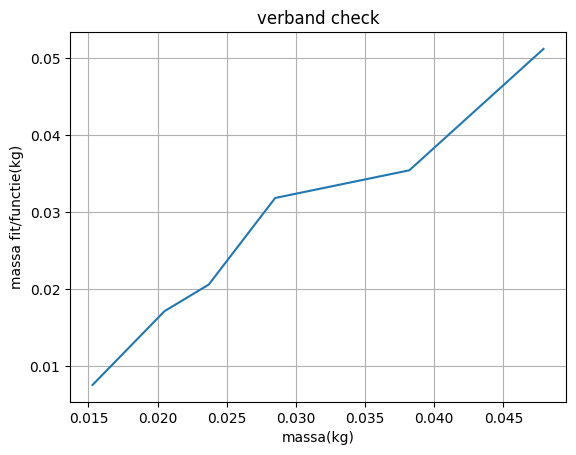

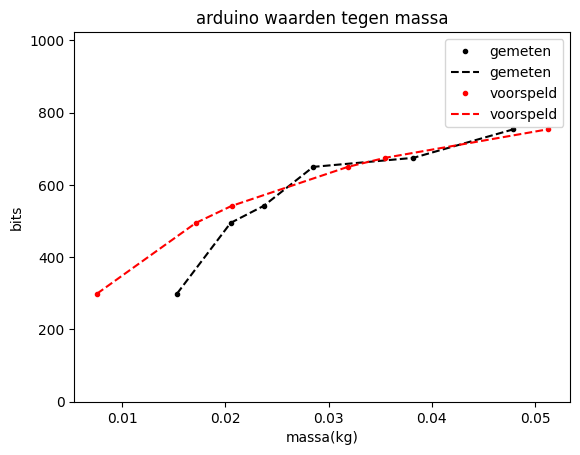

In [2]:
# Plot hier de meting en fit een lijn door de metingen.
# Maak gebruik van wat je geleerd hebt bij het practicum.

def m_gemeten(waarde_arduino, c):
    return(c*1000/((R_2*V_in*g)/(waarde_arduino*5/1023)-R_2*g))

c,f = curve_fit(m_gemeten, waarde_arduino,massa,p0=10, absolute_sigma=50)

print(c)
print(m_gemeten(750,c))

plt.title("verband check")
plt.plot(massa, m_gemeten(waarde_arduino,c))
plt.xlabel("massa(kg)")
plt.ylabel("massa fit/functie(kg)")
plt.grid()
plt.show()

#uit de plot van de curve fit tegen de massa lijkt dat het eerder benoemde verband kloppend is.

plt.title("arduino waarden tegen massa")
plt.plot(massa,waarde_arduino,"k.",label="gemeten")
plt.plot(massa,waarde_arduino,"k--",label="gemeten")
plt.plot(m_gemeten(waarde_arduino,c),waarde_arduino,"r.",label="voorspeld")
plt.plot(m_gemeten(waarde_arduino,c),waarde_arduino,"r--",label="voorspeld")
plt.xlabel("massa(kg)")
plt.ylabel("bits")
plt.ylim(0,1023)
plt.legend()
plt.show()


## *Opdracht 7*: Iteratie nodig?

Volgens ons is de sensor geschikt. iteratie dus niet nodig.

## *Opdracht 8*: Conclusie, leerdoel

Door een combinatie van de skills die we eerder bij def en IP hebben geleerd is het ons gelukt om het verband die al vast stond voor een Force Sensitive Resistor te bevestigen. namelijk R=c/f waarbij c een constante waarde is die voor onze druksensor 8.97 is.

## *Opdracht 9*: Aantonen leerdoelen beheersing

Om aan te tonen dat je de leerdoelen beheerst, kopieer je hieronder alle cellen met 'leerdoel' in de titel. Zet zelf de cellen onder de goede kopjes. Mogelijk komt een cel bij meerdere leerdoelen terug.

### Leerdoel 1: Simpele circuits (RC-circuit, spanningsdelers met sensoren) ontwerpen en fabriceren.

Kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 1 beheersen.
 ![Alt](Tekening_3.jpeg "schets student")
 ![Alt](Foto_1.jpeg "meetopstelling student")

### Leerdoel 2: Ontwerpeisen voor een opdracht SMART opstellen en vervolgens de ontwerpcyclus inrichten, rekening houdend met de randvoorwaarde van de opdracht.

Kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 2 beheersen.
Vul onderstaande tabel in en geef aan met welke sensor je verder gaat.** Laat dit aan je TA zien.** Als je TA druk is: ga wel ondertussen door met de volgende stap.

| Sensor | Toepassing | Criteria |
|:---|:---|:---|
|Krachtsensor | Luchtdruksensor | een range van 1000 n/m^2 tot 300n/m^2, resolutie van 0.6 n/m^2|
|Krachtsensor | Keuken Weegschaal | range van 50 N tot 0.1 N, resolutie 0.2 N |
|krachtsensor | Microfoon | range van 0.001 N/m^2 tot 1 N/m^2, resolutie 0.001 N/m^2, update frequentie 20000 hz|
|Lichtsensor | absorptie coefficient meten | range 100000 Lux tot 1 lux, en een resolutie van 1 lux|
|Lichtsensor | lichtmeter voor camera | range van tussen de 100000 lux en 10 lux, gevoeligheid van 100 lux |
|Lichtsensor | laser alarm | range 100000 lux tot 0.1 Lux, resolutie van 10000|
|Hall-effectsensor | Timing remmen achtbaan | range van 1 Tesla tot 1 mTesla, resolutie van 1mTesla, update frequentie van 10000 hz |
|Hall-effectsensor | Hoek van as meten | iets kunnen meten van 0 tot 360 graden, resolutie van 1 graad, zelfde afstand behouden van mageneet |
|Hall-effectsensor | positie op ass weergeven | range van 1 Tesla tot 1 mTesla en een update frequentie van 100hz |

Groep 19 heeft gekozen voor sensor krachtsensor. 

### Leerdoel 3: Voor een gegeven sensor & analoog-digitaal convertor en gegeven (of zelf gekozen) toepassing een kalibratie meting ontwerpen, inclusief het circuit om de sensor aan te sluiten op de analoog-digitaal convertor, de opstelling bouwen, en meetresultaten verwerken en concluderen of de combinatie van sensor en analoog-digitaal conversie geschikt is voor de toepassing.

In [ ]:
def m_gemeten(waarde_arduino, c):
    return(c*1000/((R_2*V_in*g)/(waarde_arduino*5/1023)-R_2*g))

c,f = curve_fit(m_gemeten, waarde_arduino,massa,p0=10, absolute_sigma=50)

print(c)
print(m_gemeten(750,c))

plt.title("verband check")
plt.plot(massa, m_gemeten(waarde_arduino,c))
plt.xlabel("massa(kg)")
plt.ylabel("massa fit/functie(kg)")
plt.grid()
plt.show()

#uit de plot van de curve fit tegen de massa lijkt dat het eerder benoemde verband kloppend is.

plt.title("arduino waarden tegen massa")
plt.plot(massa,waarde_arduino,"k.",label="gemeten")
plt.plot(massa,waarde_arduino,"k--",label="gemeten")
plt.plot(m_gemeten(waarde_arduino,c),waarde_arduino,"r.",label="voorspeld")
plt.plot(m_gemeten(waarde_arduino,c),waarde_arduino,"r--",label="voorspeld")
plt.xlabel("massa(kg)")
plt.ylabel("bits")
plt.ylim(0,1023)
plt.legend()
plt.show()



Door een combinatie van de skills die we eerder bij def en IP hebben geleerd is het ons gelukt om het verband die al vast stond voor een Force Sensitive Resistor te bevestigen. namelijk R=c/f waarbij c een constante waarde is die voor onze druksensor 8.97 is.

